<a href="https://colab.research.google.com/github/neel-madhav/CreditRiskModelling/blob/main/CreditRiskModelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [365]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [366]:
df_bureaudata = pd.read_csv('bureau_data.csv')
df_customerdata = pd.read_csv('customers.csv')
df_loandata = pd.read_csv('loans.csv')
df_bureaudata.shape, df_customerdata.shape, df_loandata.shape

((50000, 8), (50000, 12), (50000, 15))

In [367]:
df = pd.merge(df_customerdata, df_loandata, on='cust_id')
df = pd.merge(df, df_bureaudata)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [368]:
df['default'] = df['default'].astype(int)
df.default.value_counts()

,count
default,
0,45703
1,4297


## Data Leakage

In [369]:
X = df.drop("default", axis = "columns")
Y = df["default"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size =0.25, random_state=45)
df_train = pd.concat([X_train, Y_train], axis = "columns")
df_test = pd.concat([X_test, Y_test], axis = "columns")
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 6642 to 6558
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      37500 non-null  object 
 1   age                          37500 non-null  int64  
 2   gender                       37500 non-null  object 
 3   marital_status               37500 non-null  object 
 4   employment_status            37500 non-null  object 
 5   income                       37500 non-null  int64  
 6   number_of_dependants         37500 non-null  int64  
 7   residence_type               37453 non-null  object 
 8   years_at_current_address     37500 non-null  int64  
 9   city                         37500 non-null  object 
 10  state                        37500 non-null  object 
 11  zipcode                      37500 non-null  int64  
 12  loan_id                      37500 non-null  object 
 13  loan_purpose       

# Data Cleaning


In [370]:
df_train.isna().sum()

,0
cust_id,0
age,0
gender,0
marital_status,0
employment_status,0
income,0
number_of_dependants,0
residence_type,47
years_at_current_address,0
city,0


In [371]:
df_test.isna().sum()

,0
cust_id,0
age,0
gender,0
marital_status,0
employment_status,0
income,0
number_of_dependants,0
residence_type,15
years_at_current_address,0
city,0


In [372]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [373]:
df_test.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [374]:
mode_ = df_train.residence_type.mode()[0]
mode_

'Owned'

In [375]:
mode__ = df_test.residence_type.mode()[0]
mode__

'Owned'

In [376]:
df_train['residence_type'] = df_train['residence_type'].fillna(mode_)
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [377]:
df_test['residence_type'] = df_test['residence_type'].fillna(mode__)
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [378]:
df_train.duplicated().sum()

np.int64(0)

In [379]:
df_test.duplicated().sum()

np.int64(0)

In [380]:

# Numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

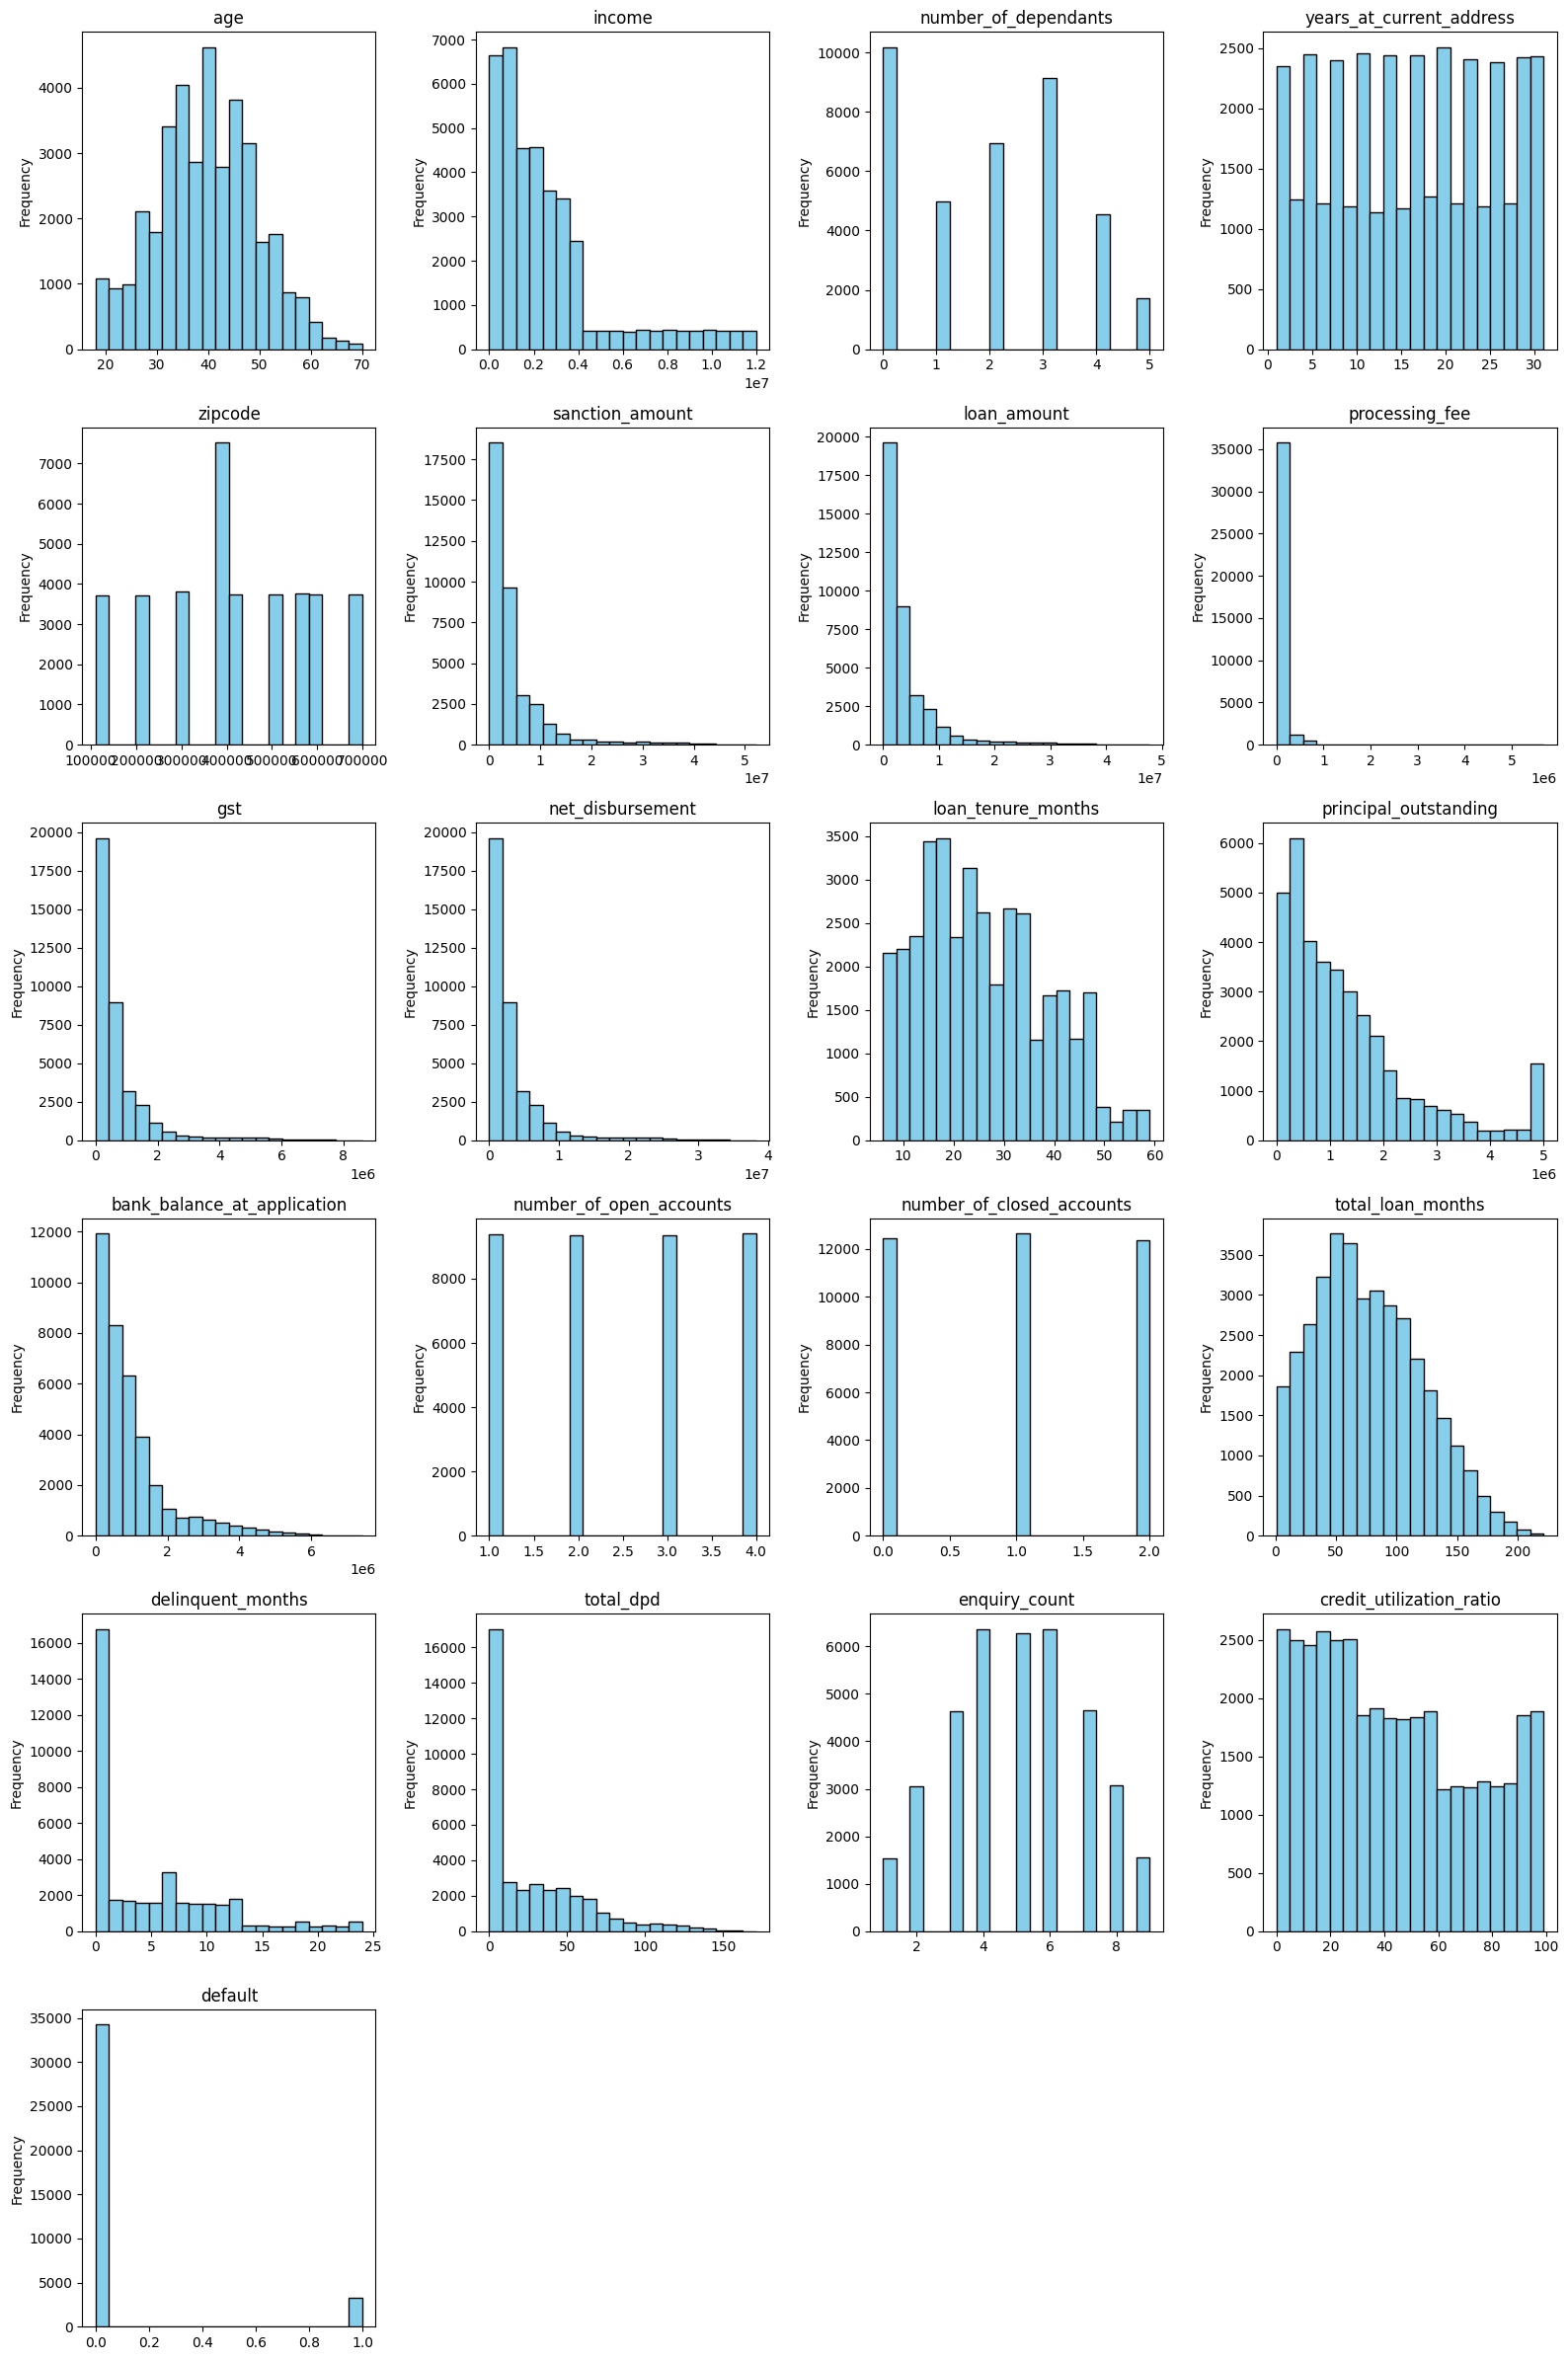

In [381]:
# Select only numeric columns
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

# Number of columns in grid
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # ceiling division

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()  # make 1D array for easy iteration

# Plot histograms
for i, col in enumerate(num_cols):
    axes[i].hist(df_train[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel("Frequency")

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [382]:
df_train.processing_fee.describe().round(2)


,processing_fee
count,37500.00
mean,80339.09
std,115722.75
min,0.00
25%,19360.00
50%,44860.00
75%,92425.00
max,5678020.86


In [383]:
df_test.processing_fee.describe().round(2)

,processing_fee
count,12500.00
mean,80961.56
std,121960.12
min,0.00
25%,19260.00
50%,44600.00
75%,91885.00
max,5698029.90


In [384]:
# Group by loan_amount and get max processing_fee
max_fee_per_loan = df_train.groupby('loan_amount')['processing_fee'].max().reset_index()

# Rename columns for clarity
max_fee_per_loan.columns = ['loan_amount', 'max_processing_fee']

print(max_fee_per_loan.tail())


       loan_amount  max_processing_fee
10837     45915000            918300.0
10838     46578000            931560.0
10839     46720000            934400.0
10840     47667000            953340.0
10841     47819000            956380.0


In [385]:
# Group by loan_amount and get max processing_fee
max_fee_per_loan_ = df_test.groupby('loan_amount')['processing_fee'].max().reset_index()

# Rename columns for clarity
max_fee_per_loan_.columns = ['loan_amount', 'max_processing_fee']

print(max_fee_per_loan_.tail())


      loan_amount  max_processing_fee
6451     41847000            836940.0
6452     42279000            845580.0
6453     42879000            857580.0
6454     46086000            921720.0
6455     47173000            943460.0


In [386]:
# Get the index of the row with max processing_fee
idx = df_train['processing_fee'].idxmax()

# Get the loan_amount for that row
loan_for_max_fee = df_train.loc[idx, 'loan_amount']
max_fee = df_train.loc[idx, 'processing_fee']

print(f"Maximum processing fee: {max_fee}")
print(f"Loan amount for maximum processing fee: {loan_for_max_fee}")


Maximum processing fee: 5678020.859009997
Loan amount for maximum processing fee: 3812000


In [387]:
# Create a mask where processing_fee > 3% of loan_amount
high_fee_mask = df_train['processing_fee'] > 0.03 * df_train['loan_amount']

# Filter the rows
high_fee_df = df_train[high_fee_mask]
high_fee_df.shape


(5, 33)

In [388]:
df_train = df_train[df_train['processing_fee'] < 0.03 * df_train['loan_amount']]


In [389]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 6642 to 6558
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      37488 non-null  object 
 1   age                          37488 non-null  int64  
 2   gender                       37488 non-null  object 
 3   marital_status               37488 non-null  object 
 4   employment_status            37488 non-null  object 
 5   income                       37488 non-null  int64  
 6   number_of_dependants         37488 non-null  int64  
 7   residence_type               37488 non-null  object 
 8   years_at_current_address     37488 non-null  int64  
 9   city                         37488 non-null  object 
 10  state                        37488 non-null  object 
 11  zipcode                      37488 non-null  int64  
 12  loan_id                      37488 non-null  object 
 13  loan_purpose       

In [390]:
num_cols

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [391]:
cat_cols

Index(['cust_id', 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_id', 'loan_purpose',
       'loan_type', 'disbursal_date', 'installment_start_dt'],
      dtype='object')

In [392]:
for col in cat_cols:
  print(col, "-->", df_train[col].unique())

cust_id --> ['C06643' 'C33294' 'C30040' ... 'C12896' 'C06013' 'C06559']
gender --> ['F' 'M']
marital_status --> ['Single' 'Married']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Jaipur' 'Delhi' 'Lucknow' 'Bangalore' 'Pune' 'Mumbai' 'Hyderabad'
 'Chennai' 'Kolkata' 'Ahmedabad']
state --> ['Rajasthan' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Maharashtra' 'Telangana'
 'Tamil Nadu' 'West Bengal' 'Gujarat']
loan_id --> ['L06643' 'L33294' 'L30040' ... 'L12896' 'L06013' 'L06559']
loan_purpose --> ['Auto' 'Personal' 'Home' 'Education' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
disbursal_date --> ['2020-03-23' '2022-11-20' '2022-07-25' ... '2023-08-07' '2021-07-02'
 '2021-08-22']
installment_start_dt --> ['2020-04-10' '2022-12-13' '2022-08-23' ... '2024-08-14' '2019-07-28'
 '2024-08-20']


In [393]:
df_train["loan_purpose"] = df_train["loan_purpose"].replace('Personaal', 'Personal')
df_test["loan_purpose"] = df_test["loan_purpose"].replace('Personaal', 'Personal')
df_train["loan_purpose"].unique()

array(['Auto', 'Personal', 'Home', 'Education'], dtype=object)

# Exploratory Data Analysis

/tmp/ipython-input-601285610.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_train[col][df_train['default']==0], label='default0', fill=True)
/tmp/ipython-input-601285610.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_train[col][df_train['default']==1], label='default1', fill=True)


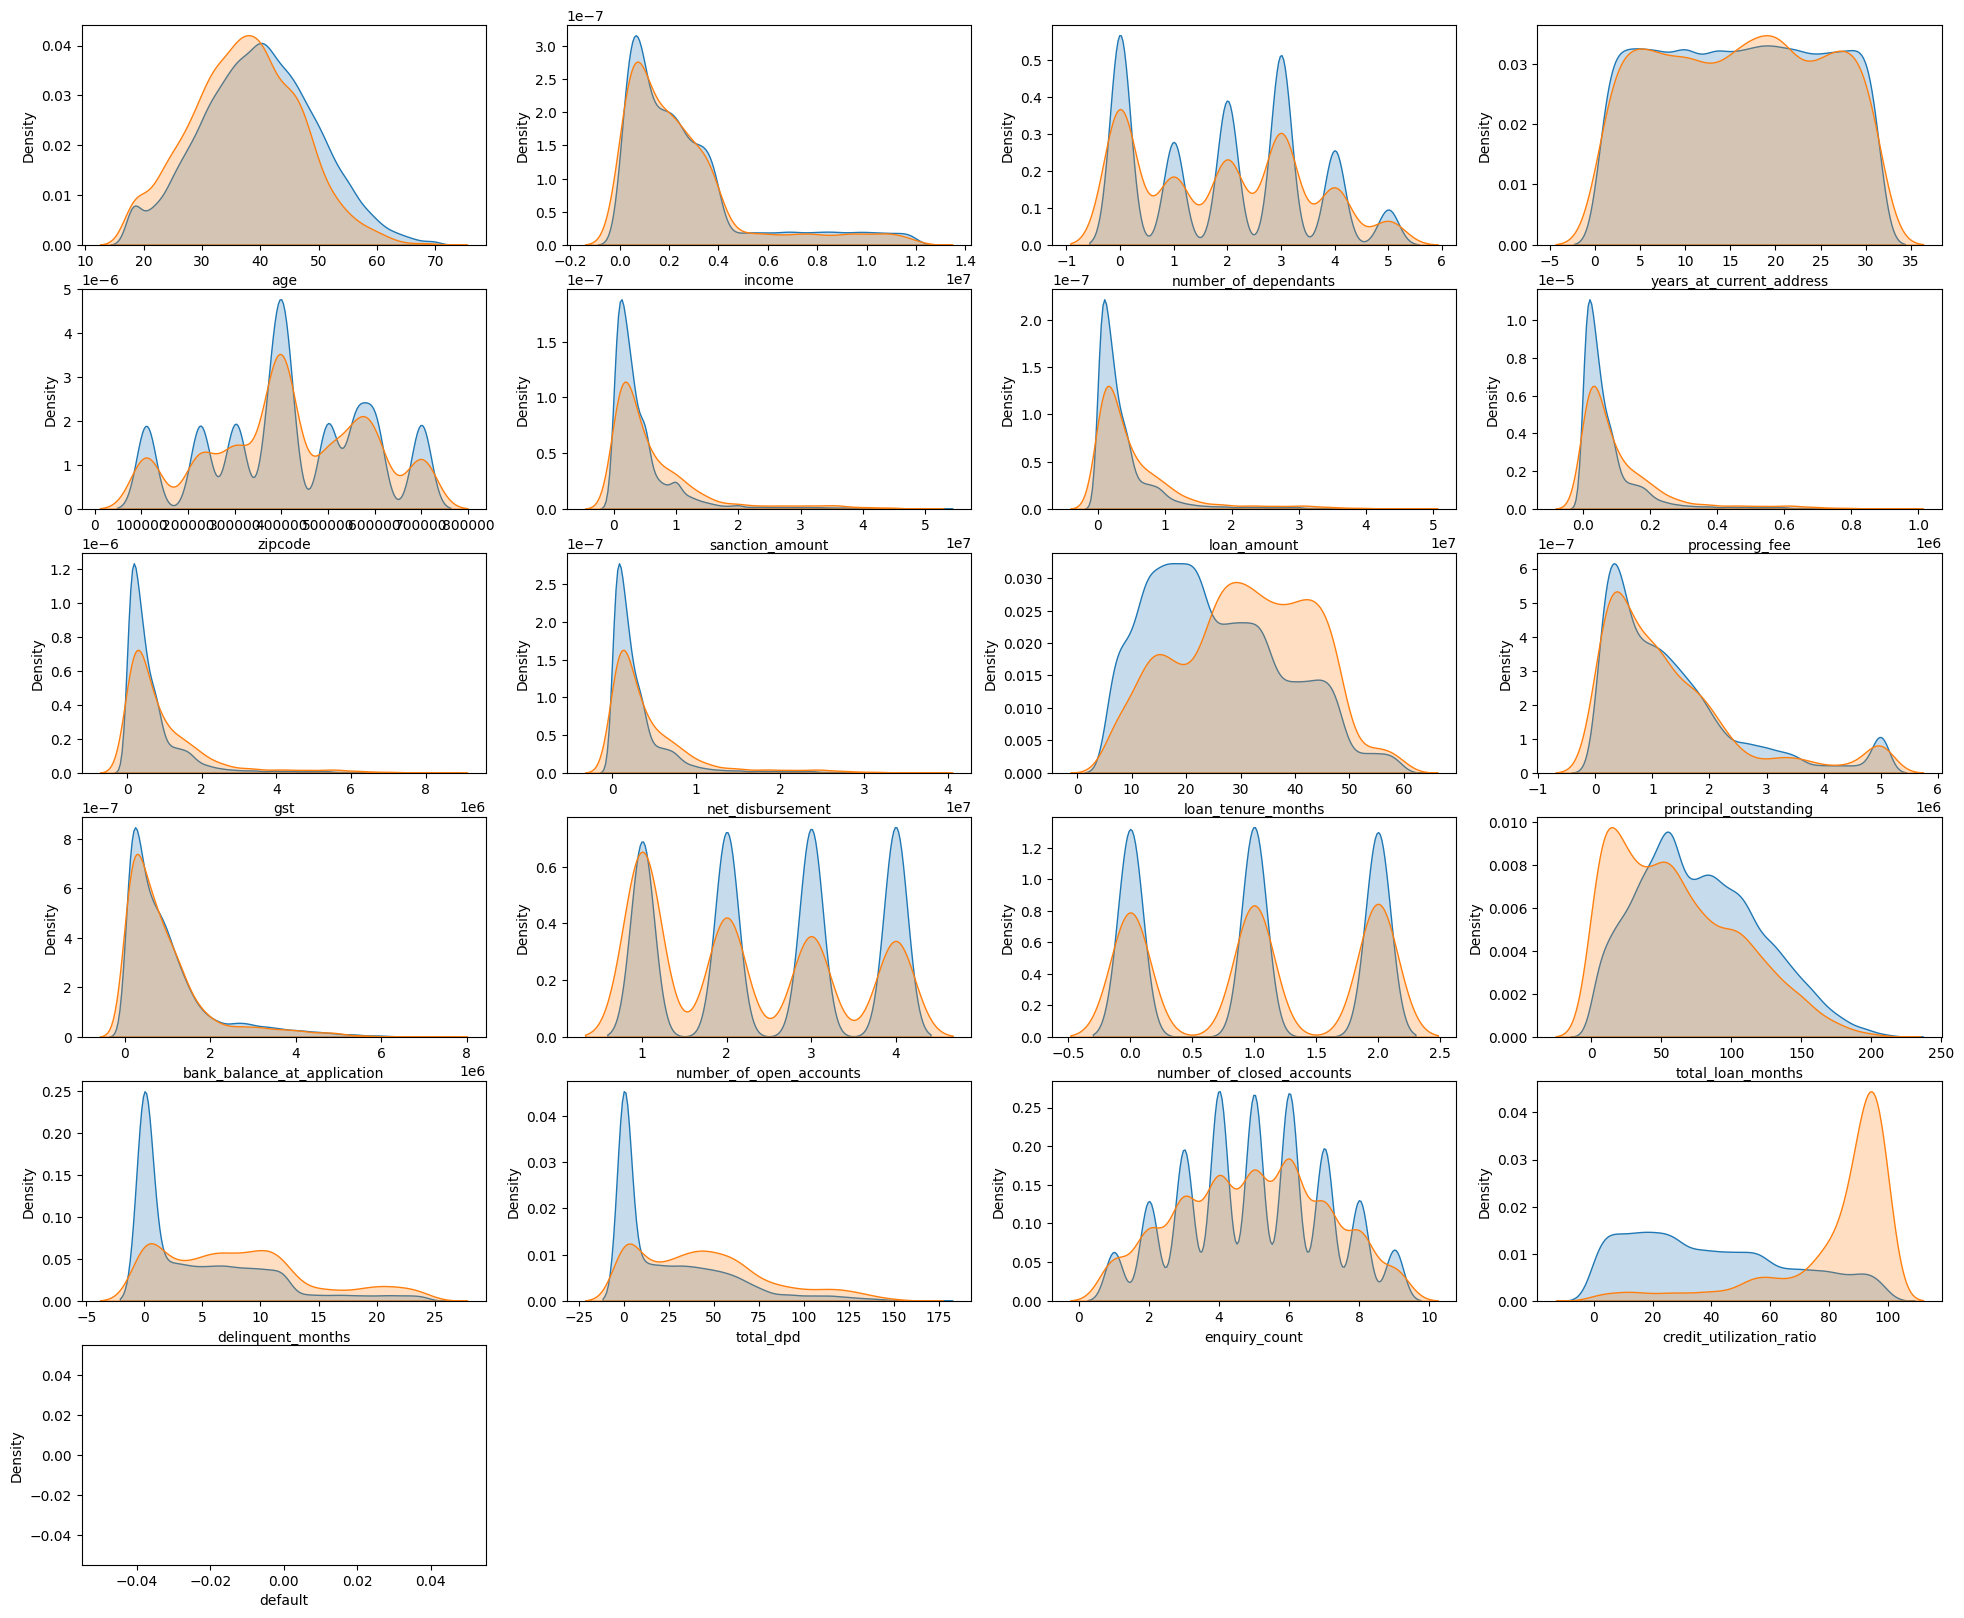

In [394]:

plt.figure(figsize=(24,20))
for i, col in enumerate(num_cols):
    plt.subplot(6, 4, i + 1)
    sns.kdeplot(df_train[col][df_train['default']==0], label='default0', fill=True)
    sns.kdeplot(df_train[col][df_train['default']==1], label='default1', fill=True)

plt.show()


<Axes: xlabel='loan_income', ylabel='Density'>

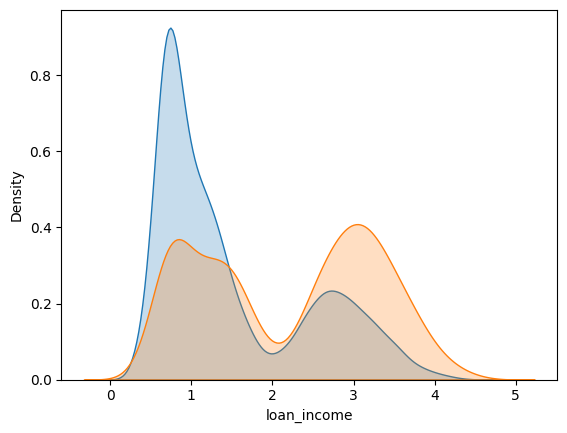

In [395]:
df_train["loan_income"] = round(df_train["loan_amount"] / df_train["income"],2)
df_test["loan_income"] = round(df_test["loan_amount"] / df_test["income"],2)
sns.kdeplot(df_train["loan_income"][df_train['default']==0], label='default0', fill=True)
sns.kdeplot(df_train["loan_income"][df_train['default']==1], label='default1', fill=True)

When Loan amount to income ratio is higher you are more likely to default.

<Axes: xlabel='delinquent_Loan', ylabel='Density'>

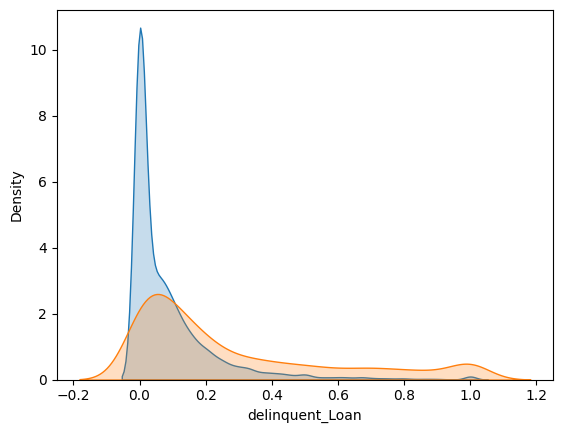

In [396]:
df_train["delinquent_Loan"] = round(df_train["delinquent_months"] / df_train["total_loan_months"],2)
df_test["delinquent_Loan"] = round(df_test["delinquent_months"] / df_test["total_loan_months"],2)
sns.kdeplot(df_train["delinquent_Loan"][df_train['default']==0], label='default0', fill=True)
sns.kdeplot(df_train["delinquent_Loan"][df_train['default']==1], label='default1', fill=True)

This shows your deliqunecy ratio is lower then you will not default. Higher the value higher the chances of default

<Axes: xlabel='dpd_delinquent', ylabel='Density'>

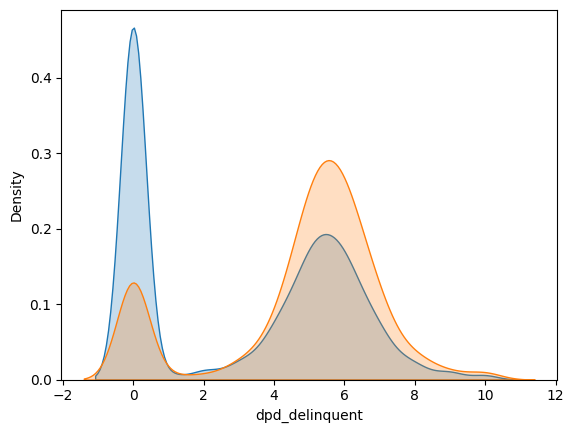

In [397]:
df_train["dpd_delinquent"] = np.where(df_train["delinquent_months"] != 0,df_train["total_dpd"] / df_train["delinquent_months"], 0)
df_test["dpd_delinquent"] = np.where(df_test["delinquent_months"]!= 0,df_test["total_dpd"] / df_test["delinquent_months"], 0)
sns.kdeplot(df_train["dpd_delinquent"][df_train['default']==0], label='default0', fill=True)
sns.kdeplot(df_train["dpd_delinquent"][df_train['default']==1], label='default1', fill=True)

Higher values results in default

# Feature Selection

In [398]:
df_train

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default,loan_income,delinquent_Loan,dpd_delinquent
6642,C06643,31,F,Single,Self-Employed,812000,0,Owned,5,Jaipur,...,0,18,8,56,6,37,0,1.15,0.44,7.000000
33293,C33294,55,F,Married,Self-Employed,3010000,2,Mortgage,10,Delhi,...,2,58,10,49,2,54,0,0.64,0.17,4.900000
30039,C30040,41,F,Married,Salaried,937000,3,Owned,27,Lucknow,...,2,88,1,2,3,87,0,2.96,0.01,2.000000
30232,C30233,50,F,Married,Self-Employed,3050000,4,Mortgage,25,Bangalore,...,1,32,0,0,1,27,0,3.00,0.00,0.000000
36193,C36194,53,M,Married,Self-Employed,508000,3,Owned,13,Pune,...,0,94,0,0,8,7,0,0.62,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32469,C32470,28,F,Married,Self-Employed,193000,2,Rented,22,Mumbai,...,1,143,4,23,9,19,0,0.87,0.03,5.750000
16317,C16318,38,M,Married,Self-Employed,1858000,2,Mortgage,26,Kolkata,...,1,93,4,29,6,89,0,0.86,0.04,7.250000
12895,C12896,49,M,Married,Self-Employed,916000,3,Mortgage,17,Delhi,...,1,29,0,0,6,35,0,0.68,0.00,0.000000
6012,C06013,41,M,Married,Salaried,315000,2,Rented,13,Kolkata,...,1,29,0,0,6,13,0,0.96,0.00,0.000000


In [399]:
df_train=df_train.drop(["cust_id", "loan_id", "disbursal_date", "installment_start_dt", "loan_amount", "income", "total_loan_months", "delinquent_months", "total_dpd"], axis = "columns")
df_test=df_test.drop(["cust_id", "loan_id", "disbursal_date", "installment_start_dt", "loan_amount", "income", "total_loan_months", "delinquent_months", "total_dpd"], axis = "columns")
df_train.columns


Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_income', 'delinquent_Loan',
       'dpd_delinquent'],
      dtype='object')

In [400]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 6642 to 6558
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  int64  
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  int64  
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  int64  
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  int64  
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  sanction_amount              37488 non-null  int64  
 13  processing_fee     

In [401]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12500 entries, 42462 to 11244
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          12500 non-null  int64  
 1   gender                       12500 non-null  object 
 2   marital_status               12500 non-null  object 
 3   employment_status            12500 non-null  object 
 4   number_of_dependants         12500 non-null  int64  
 5   residence_type               12500 non-null  object 
 6   years_at_current_address     12500 non-null  int64  
 7   city                         12500 non-null  object 
 8   state                        12500 non-null  object 
 9   zipcode                      12500 non-null  int64  
 10  loan_purpose                 12500 non-null  object 
 11  loan_type                    12500 non-null  object 
 12  sanction_amount              12500 non-null  int64  
 13  processing_fee   

In [402]:
X_Train = df_train.drop('default', axis = 'columns')
Y_Train = df_train['default']
X_Test = df_test.drop('default', axis = 'columns')
Y_Test = df_test['default']


In [403]:
scaler = MinMaxScaler()
col_to_scale = X_Train.select_dtypes(include=['int64', 'float64']).columns
X_Train[col_to_scale] = scaler.fit_transform(X_Train[col_to_scale])
X_Train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_income,delinquent_Loan,dpd_delinquent
count,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000
mean,0.413603,0.389399,0.500595,0.523948,0.088694,0.082479,0.082479,0.082479,0.376073,0.262058,0.131018,0.500347,0.498720,0.500660,0.438257,0.292694,0.104139,0.330241
std,0.188703,0.307024,0.297701,0.286174,0.119617,0.112173,0.112173,0.112173,0.234460,0.244189,0.141243,0.373009,0.407008,0.253701,0.296617,0.226569,0.173391,0.290295
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.020595,0.019094,0.019094,0.019094,0.188679,0.078651,0.036322,0.000000,0.000000,0.375000,0.181818,0.109557,0.000000,0.000000
50%,0.423077,0.400000,0.500000,0.491525,0.049519,0.045789,0.045789,0.045789,0.339623,0.194370,0.087646,0.666667,0.500000,0.500000,0.393939,0.200466,0.040000,0.433333
75%,0.538462,0.600000,0.766667,0.762712,0.098064,0.095576,0.095576,0.095576,0.547170,0.353690,0.164750,1.000000,1.000000,0.625000,0.676768,0.503497,0.130000,0.575000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [404]:
col_to_scale = X_Test.select_dtypes(include=['int64', 'float64']).columns
X_Test[col_to_scale] = scaler.transform(X_Test[col_to_scale])
X_Test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_income,delinquent_Loan,dpd_delinquent
count,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12499.000000,12500.000000,12500.000000
mean,0.416915,0.383344,0.500667,0.523780,0.089508,0.083581,0.082892,0.082892,0.376773,0.263284,0.131146,0.499013,0.506040,0.502710,0.437223,0.292398,0.103625,0.328342
std,0.191385,0.307322,0.297091,0.287144,0.122328,0.127672,0.113780,0.113780,0.234970,0.246098,0.141673,0.372692,0.407182,0.253489,0.296291,0.226305,0.171999,0.290851
min,0.000000,0.000000,0.000000,0.000000,-0.001420,-0.001172,-0.001172,-0.001172,0.000000,-0.007088,-0.002624,0.000000,0.000000,0.000000,0.000000,0.002331,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.020671,0.018990,0.018990,0.018990,0.188679,0.077770,0.035729,0.000000,0.000000,0.375000,0.181818,0.109557,0.000000,0.000000
50%,0.423077,0.400000,0.500000,0.491525,0.049577,0.045516,0.045516,0.045516,0.339623,0.195799,0.088023,0.666667,0.500000,0.500000,0.393939,0.200466,0.040000,0.433333
75%,0.538462,0.600000,0.766667,0.762712,0.097340,0.095016,0.094979,0.094979,0.547170,0.353264,0.164913,0.666667,1.000000,0.750000,0.676768,0.501166,0.130000,0.575000
max,1.000000,1.000000,1.000000,1.000000,0.999079,5.963727,0.986475,0.986475,1.000000,1.000000,1.057748,1.000000,1.000000,1.000000,1.000000,0.995338,1.000000,1.000000


In [405]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
  vif_df = pd.DataFrame()
  vif_df['column'] = data.columns
  vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
  return vif_df

In [406]:
calculate_vif(X_Train[col_to_scale])

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,column,VIF
0,age,5.753169
1,number_of_dependants,2.735971
2,years_at_current_address,3.419421
3,zipcode,3.801400
4,sanction_amount,100.976292
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.119099
9,principal_outstanding,16.370549


In [407]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement', 'principal_outstanding']
X_Train = X_Train.drop(features_to_drop_vif, axis='columns')
numeric_col = X_Train.select_dtypes(include=['int64', 'float64']).columns
X_Test = X_Test.drop(features_to_drop_vif, axis='columns')

In [410]:
vif_df = calculate_vif(X_Train[numeric_col])

In [412]:
selected_numeric_features_vif = vif_df.column.values